In [1]:
# =========================================================
# Google Stock Price Prediction using RNN
# Colab-ready, simple and easy to remember
# =========================================================

In [2]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout

In [3]:
# 2. Load dataset directly from GitHub
train_url = "https://raw.githubusercontent.com/kevincwu0/rnn-google-stock-prediction/master/Google_Stock_Price_Train.csv"
test_url  = "https://raw.githubusercontent.com/Parasgr7/Google-Stock-Price-Prediction/master/Google_Stock_Price_Test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print(train_df.head())

Train shape: (1258, 6)
Test shape : (20, 6)
       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800


In [4]:
# 3. Use only the 'Open' price column
training_set = train_df[['Open']].values
real_stock_price = test_df[['Open']].values

In [5]:
# 4. Scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = scaler.fit_transform(training_set)

In [6]:
# 5. Create sequences of 60 timesteps
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# RNN expects 3D input: [samples, timesteps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1198, 60, 1)
y_train shape: (1198,)


In [7]:
# 6. Build the RNN model
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# 7. Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

In [9]:
# 8. Train model
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.2783 - val_loss: 0.0021
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1327 - val_loss: 0.0078
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0713 - val_loss: 0.0021
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0495 - val_loss: 0.0141
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0408 - val_loss: 0.0036
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0311 - val_loss: 0.0014
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0235 - val_loss: 5.8358e-04
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0201 - val_loss: 4.7310e-04
Epoch 9/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0182 - val_loss: 0.0015
Epoch 10/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0149 - val_loss: 7.8769e-04
Epoch 11/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0154 - val_loss: 0.0019
Epoch 12/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

In [10]:
# 9. Prepare test data
dataset_total = pd.concat((train_df['Open'], test_df['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_df) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(60, 60 + len(test_df)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print("X_test shape:", X_test.shape)

X_test shape: (20, 60, 1)


In [11]:
# 10. Predict
predicted_stock_price = model.predict(X_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


In [12]:
# 11. Evaluation
mse = mean_squared_error(real_stock_price, predicted_stock_price)
rmse = np.sqrt(mse)
mae = mean_absolute_error(real_stock_price, predicted_stock_price)

print("\nEvaluation Metrics")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)


Evaluation Metrics
MSE  : 668.6192274985774
RMSE : 25.85767250737346
MAE  : 24.01183837890624


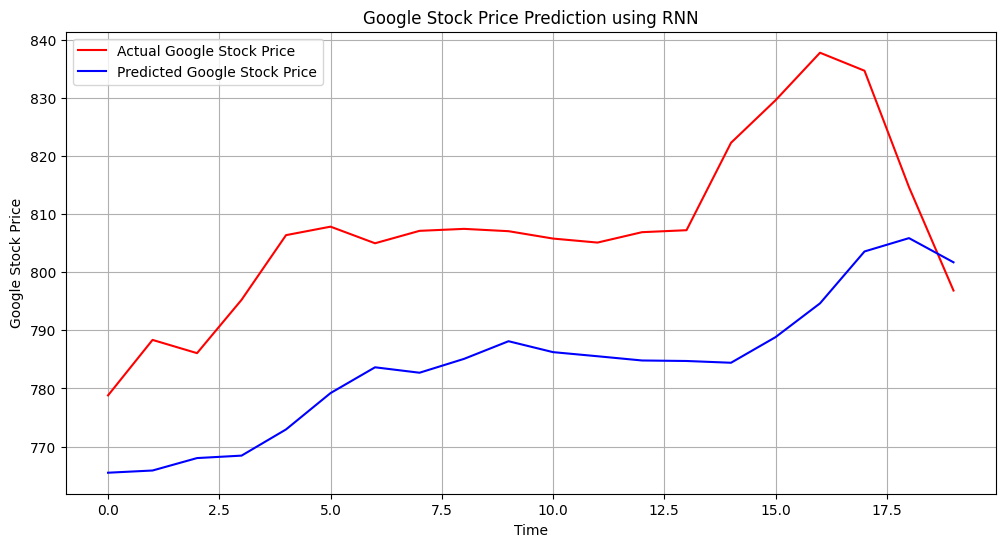

In [13]:
# 12. Plot actual vs predicted stock price
plt.figure(figsize=(12, 6))
plt.plot(real_stock_price, color='red', label='Actual Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction using RNN')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.grid(True)
plt.show()

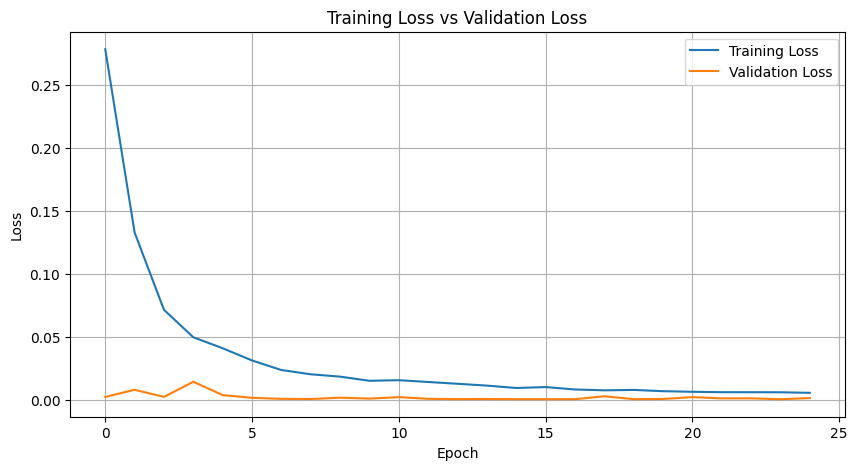

In [14]:
# 13. Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 14. Compare first few predictions
results = pd.DataFrame({
    'Actual Price': real_stock_price.flatten(),
    'Predicted Price': predicted_stock_price.flatten()
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual Price  Predicted Price
0        778.81       765.491394
1        788.36       765.872681
2        786.08       768.014343
3        795.26       768.434509
4        806.40       772.947144
5        807.86       779.205261
6        805.00       783.643982
7        807.14       782.709351
8        807.48       785.094788
9        807.08       788.133789


In [16]:
# 15. Optional: predict next day price after last available point
last_60_days = dataset_total.values[-60:].reshape(-1, 1)
last_60_days_scaled = scaler.transform(last_60_days)
X_future = np.array([last_60_days_scaled[:, 0]])
X_future = np.reshape(X_future, (X_future.shape[0], X_future.shape[1], 1))

next_day_pred = model.predict(X_future)
next_day_pred = scaler.inverse_transform(next_day_pred)

print("\nPredicted next day opening price:", next_day_pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step

Predicted next day opening price: 791.9744
